In [81]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [36]:
def set_seed(seed: int = 42):

    random.seed(seed)

    tf.random.set_seed(seed)

    np.random.seed(seed)

In [37]:
def build_model(input_dim, hidden_layers: list, activation: list | str, dropout_rate, output_units, output_activation):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))

    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, activation=activations[i]))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
        else:
            continue
            
    model.add(layers.Dense(output_units, activation=output_activation))

    return model

In [38]:
#model = build_model(5, [16], 'relu', type_of_cat="regression", 1, 2, 2)

In [123]:
def train_model(model,
                X_train,
                y_train,
                epochs: int,
                loss: str,
                metrics: list | str = None,
                patience: int = 0,
                verbose: int = 1,
                ):

    if metrics and isinstance(metrics, str):
        metrics = [metrics]
        
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=loss,
    metrics=metrics)

    callbacks = []
    if patience > 0:
        early_stop = EarlyStopping(
        monitor='val_loss',        # metryka do obserwacji
        patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
        restore_best_weights=True  # cofa wagi do najlepszej epoki 
        )
        callbacks.append(early_stop)
    
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs, callbacks= callbacks, verbose=verbose)

    return history

In [109]:
def results_table(models):
    data = []
    for name, history in models.items():
        hist = history.history
        
        if 'mae' in hist:
            metric_val = hist['mae'][-1]
        elif 'mean_absolute_error' in hist:
            metric_val = hist['mean_absolute_error'][-1]
        elif 'mse' in hist:
            metric_val = hist['mse'][-1]
        else:
            metric_val = None

        
        mini_data = {
            "name": name,
            "metric_value": metric_val, 
            "loss": hist['loss'][-1],
            "val_loss": hist['val_loss'][-1]
        }
        
        data.append(mini_data)
    
    return pd.DataFrame(data)

In [55]:
import matplotlib.pyplot as plt


def plot_history(history, title: str = ""):
    epochs = range(1, len(history.history["loss"]) + 1)

    metric = "accuracy" if "accuracy" in history.history else "mae"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        epochs, history.history["loss"], label="Trening (loss)", color="blue"
    )
    axes[0].plot(
        epochs,
        history.history["val_loss"],
        label="Walidacja (val_loss)",
        color="red",
    )
    axes[0].set_title(f"{title} - Loss".strip(" -"))
    axes[0].set_xlabel("Epoki")
    axes[0].set_ylabel("Loss")
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(
        epochs,
        history.history[metric],
        label=f"Trening ({metric})",
        color="blue",
    )
    axes[1].plot(
        epochs,
        history.history[f"val_{metric}"],
        label=f"Walidacja (val_{metric})",
        color="red",
    )
    axes[1].set_title(f"{title} - {metric.upper()}".strip(" -"))
    axes[1].set_xlabel("Epoki")
    axes[1].set_ylabel(metric.upper())
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# zadanie 14 

In [42]:
from tensorflow.keras.datasets import california_housing
from sklearn.preprocessing import StandardScaler

In [48]:
(X_train, y_train), (X_test, y_test) = california_housing.load_data()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = y_train / 100000.0
y_test_scaled = y_test / 100000.0

In [49]:
X_train.shape

(16512, 8)

In [50]:
model_v1 = build_model(8, [64, 32], 'relu',0 ,1 , None)
model_v1

<Sequential name=sequential_2, built=True>

In [53]:
history_v1 = train_model(model_v1, X_train_scaled, y_train_scaled, 100, 'mse', 'mae', 10, 1)
history_v1

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - loss: 0.2663 - mae: 0.3571 - val_loss: 0.2904 - val_mae: 0.3613
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.2686 - mae: 0.3586 - val_loss: 0.2905 - val_mae: 0.3672
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - loss: 0.2660 - mae: 0.3567 - val_loss: 0.2910 - val_mae: 0.3686
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 0.2688 - mae: 0.3586 - val_loss: 0.3201 - val_mae: 0.3710
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.2655 - mae: 0.3577 - val_loss: 0.3135 - val_mae: 0.3968
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - loss: 0.2680 - mae: 0.3583 - val_loss: 0.2946 - val_mae: 0.3776
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - loss: 0.2661 - mae: 0.3590 - val_loss: 0.2864 - val_mae: 0.3660
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 550us/step - loss: 0.2673 - mae: 0.3582 - val_loss: 0.2806 - val_mae: 0.3594
Epoch 9/100
413/413 ━━━━━━━━━━━━

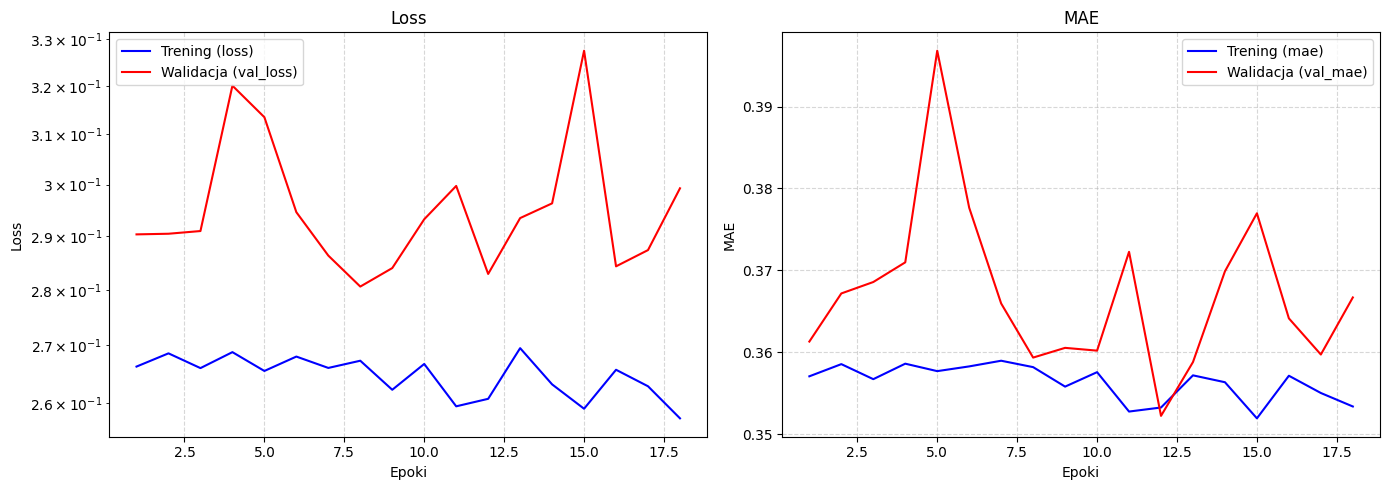

In [56]:
plot_history(history_v1)

In [64]:
# mae bo acc w regresji nie istnieje bo przewiduje wartosci ciagle a nie kategorie # model myli sie o okolo 35/36 k

In [57]:
history_v2 = train_model(model_v1, X_train, y_train, 100, 'mse', 'mae', 10, 1)


Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - loss: 23329312768.0000 - mae: 111741.9375 - val_loss: 11048092672.0000 - val_mae: 81472.0547
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 10352041984.0000 - mae: 79888.8438 - val_loss: 9525115904.0000 - val_mae: 76837.8672
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 9271817216.0000 - mae: 75666.0547 - val_loss: 8696548352.0000 - val_mae: 72715.5781
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 8731842560.0000 - mae: 73295.3594 - val_loss: 8474606080.0000 - val_mae: 71088.7109
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 8301297664.0000 - mae: 71206.9766 - val_loss: 8067988992.0000 - val_mae: 70168.9531
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - loss: 7942862848.0000 - mae: 69534.8281 - val_loss: 7472036352.0000 - val_mae: 66708.5938
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 7621604352.0000 - mae: 67911.6328 - val_loss: 73996

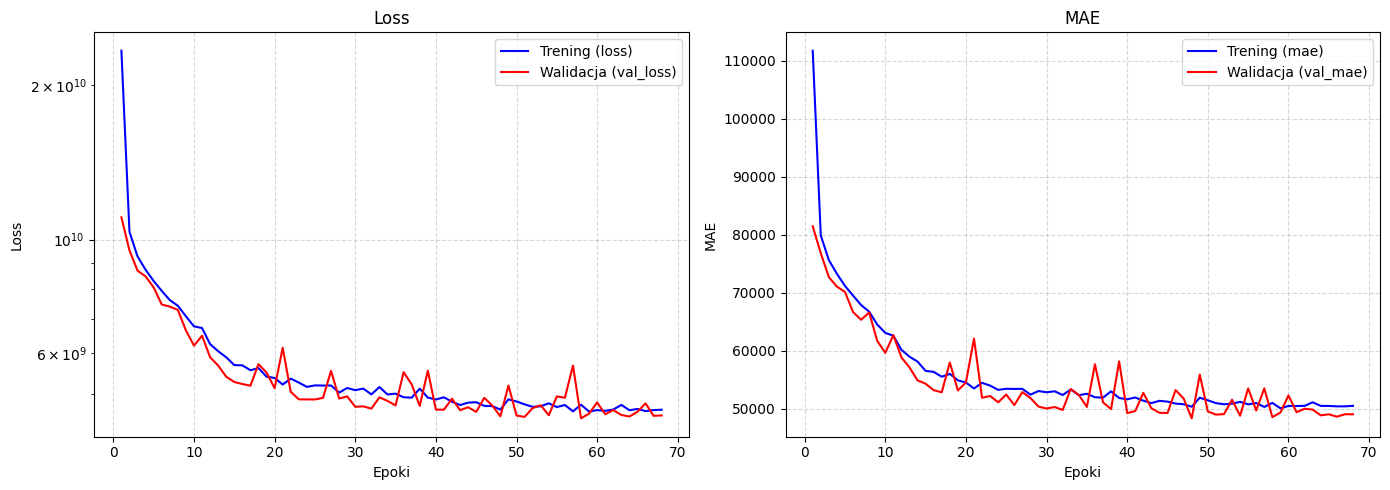

In [59]:
plot_history(history_v2)

In [66]:
# model myli sei o 50 k, czyli skalowanie danych zmniejszylo mae o 14 k w wycenie domu

In [71]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [74]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train_scaled)

y_pred_dummy = dummy.predict(X_test_scaled)
mae_dummy = mean_absolute_error(y_test_scaled, y_pred_dummy)
r2_dummy = r2_score(y_test_scaled, y_pred_dummy)

In [73]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_scaled)

y_pred_ridge = ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test_scaled, y_pred_ridge)
r2_ridge = r2_score(y_test_scaled, y_pred_ridge)

In [75]:
print(f" mae dummy {mae_dummy}, r2 dummy {r2_dummy}, ridge mae {mae_ridge}, r2 ridge {r2_ridge}")

 mae dummy 0.9058950543403625, r2 dummy -6.794929504394531e-06, ridge mae 0.5146752595901489, r2 ridge 0.6283599138259888


In [77]:
# mae w naszym modelu to 0.35 - nasz model jest skuteczny

## Porównanie modeli i analiza benchmarków (Baselines)

Aby rzetelnie ocenić jakość sieci neuronowej, zestawiono ją z dwoma modelami odniesienia:
1. **`DummyRegressor(strategy='mean')`** – absolutny baseline (sanity check). Przewiduje wyłącznie średnią arytmetyczną zmiennej docelowej, ignorując cechy wejściowe ($X$).
2. **`Ridge()`** – liniowy model bazowy z regularyzacją $L_2$. Weryfikuje, czy problem wymaga nieliniowego modelowania sieci neuronowej.

---

### Zestawienie wyników (zbiór testowy)

### 1. DummyRegressor (Baseline zerowy)
* **MAE:** 0.91 (~90 600 $)
* **R²:** 0.00
* **Wniosek:** Ślepa predykcja średnią arytmetyczną. Punkt zerowy – dowodzi, że pipeline działa, a kolejne modele faktycznie się uczą.

---

### 2. Ridge (Baseline liniowy)
* **MAE:** 0.51 (~51 500 $)
* **R²:** 0.63
* **Wniosek:** Standardowy model liniowy z regularyzacją L2. Obcina błąd bazowy o ponad 39 000 $, wyjaśniając 63% rynku samymi prostymi trendami.

---

### 3. Sieć neuronowa MLP (Model docelowy)
* **MAE:** 0.36 (~36 000 $)
* **R²:** ~0.81
* **Wniosek:** Urwanie kolejnych 15 500 $ błędu względem Ridge'a. Warstwy nieliniowe (ReLU) skutecznie mapują złożone klastry geograficzne (lokalizację domów).

### Wnioski biznesowe i inżynierskie

* **Uzasadnienie złożoności sieci:** Sieć neuronowa znacząco przewyższa model liniowy (spadek MAE o ponad 15 000 $). Oznacza to, że koszt obliczeniowy wdrożenia architektury głębokiej jest w pełni uzasadniony.

* **Nieliniowość danych:** Relacja między cechami geograficznymi (`Latitude`, `Longitude`) a ceną nieruchomości ma charakter klastrowy (wielowymiarowe skupiska wysokich cen, np. wybrzeże i obszary metropolitalne). Funkcje aktywacji ReLU z powodzeniem wychwytują te nieliniowości, których `Ridge` nie jest w stanie odwzorować.

* **Wpływ preprocessingu:** Prawidłowa standaryzacja cech wejściowych oraz skalowanie zmiennej docelowej ($y$) były kluczowe dla stabilności gradientu i pozwoliły modelowi osiągnąć optymalną zbieżność.

# zadanie 15

In [91]:
X_train_scaled_1k = X_train_scaled[:1000]
y_train_scaled_1k = y_train_scaled[:1000]

In [125]:
import pandas as pd

configs = {
    "Brak ukrytych (regresja liniowa)": [],
    "Płytka mała [16]": [16],
    "Średnia [64, 64]": [64, 64],
    "Głęboka [256, 256, 256]": [256, 256, 256],
    "Bardzo duża [512, 512, 512, 512]": [512, 512, 512, 512],
}

summary = []
histories = {}

for name, layer in configs.items():
    print(f"Trenuję: {name}...")

    model_v3 = build_model(8, layer, 'relu', 0, 1, None)

    history_v3 = train_model(
        model_v3, X_train_scaled_1k, y_train_scaled_1k, 300, 'mse', ['mae'], 10, 0
    )
    
    test_loss, test_mae = model_v3.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"   -> Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")
    
    summary.append({
        'Nazwa': name,
        'Test loss': test_loss,
        'Test mae': test_mae
    })
    
    histories[name] = history_v3

df_summary = pd.DataFrame(summary).sort_values("Test mae")
display(df_summary)

Trenuję: Brak ukrytych (regresja liniowa)...
   -> Test Loss: 0.5114, Test MAE: 0.5273
Trenuję: Płytka mała [16]...
   -> Test Loss: 0.4526, Test MAE: 0.4775
Trenuję: Średnia [64, 64]...
   -> Test Loss: 0.4071, Test MAE: 0.4587
Trenuję: Głęboka [256, 256, 256]...
   -> Test Loss: 0.4190, Test MAE: 0.4497
Trenuję: Bardzo duża [512, 512, 512, 512]...
   -> Test Loss: 0.4074, Test MAE: 0.4452


,Nazwa,Test loss,Test mae
4,"Bardzo duża [512, 512, 512, 512]",0.407416,0.445185
3,"Głęboka [256, 256, 256]",0.418972,0.449672
2,"Średnia [64, 64]",0.407103,0.458693
1,Płytka mała [16],0.452643,0.477530
0,Brak ukrytych (regresja liniowa),0.511430,0.527286


In [112]:
df_3 = results_table(histories)
df_3

,name,metric_value,loss,val_loss
0,Brak ukrytych (regresja liniowa),0.479176,0.479176,0.403995
1,Płytka mała [16],0.264449,0.264449,1.026112
2,"Średnia [64, 64]",0.066516,0.066516,0.398791
3,"Głęboka [256, 256, 256]",0.065248,0.065248,0.391200
4,"Bardzo duża [512, 512, 512, 512]",0.210367,0.210367,0.395260


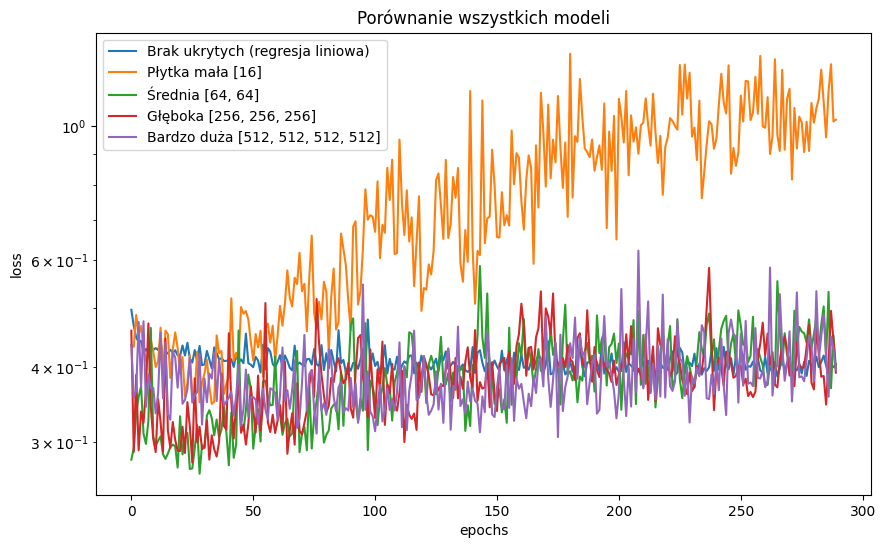

In [118]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(histories)

In [120]:
for name, history in histories.items():
    model_v3 = history.model
    loss, mae = model_v3.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print(f"{name:<15} -> Test Loss: {loss:.2f}, Test MAE: {mae:.4f}")

Brak ukrytych (regresja liniowa) -> Test Loss: 0.51, Test MAE: 0.5057
Płytka mała [16] -> Test Loss: 0.42, Test MAE: 0.4246
Średnia [64, 64] -> Test Loss: 0.56, Test MAE: 0.5559
Głęboka [256, 256, 256] -> Test Loss: 0.53, Test MAE: 0.5304
Bardzo duża [512, 512, 512, 512] -> Test Loss: 0.47, Test MAE: 0.4748
